<a href="https://colab.research.google.com/github/Thhreda/Demo/blob/main/T1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CET3013 Deep Learning — Assignment 2
## Task 1: CNN from Scratch on MNIST  


---
# Setup & Imports

In [ ]:
# Install extra packages needed
!pip install -q torchvision scikit-learn seaborn Pillow

# ── Standard library ──────────────────────────────────────────
import os, glob, time, copy, zipfile
import xml.etree.ElementTree as ET
from collections import defaultdict

# ── Numerical / plotting ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

# ── Sklearn metrics ───────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

# ── PyTorch core ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Torchvision ───────────────────────────────────────────────
import torchvision
from torchvision import datasets, transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# ── Device ────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch      : {torch.__version__}')
print(f'Torchvision  : {torchvision.__version__}')
print(f'Device       : {device}')
if torch.cuda.is_available():
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print('\nAll packages loaded successfully.')

PyTorch      : 2.10.0+cu128
Torchvision  : 0.25.0+cu128
Device       : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB

All packages loaded successfully.



#
# TASK 1 — CNN FROM SCRATCH ON MNIST
#

## T1-1 · Data Loading & Preprocessing

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]


Train samples : 60,000
Test  samples : 10,000
Classes       : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Image shape   : torch.Size([1, 28, 28])


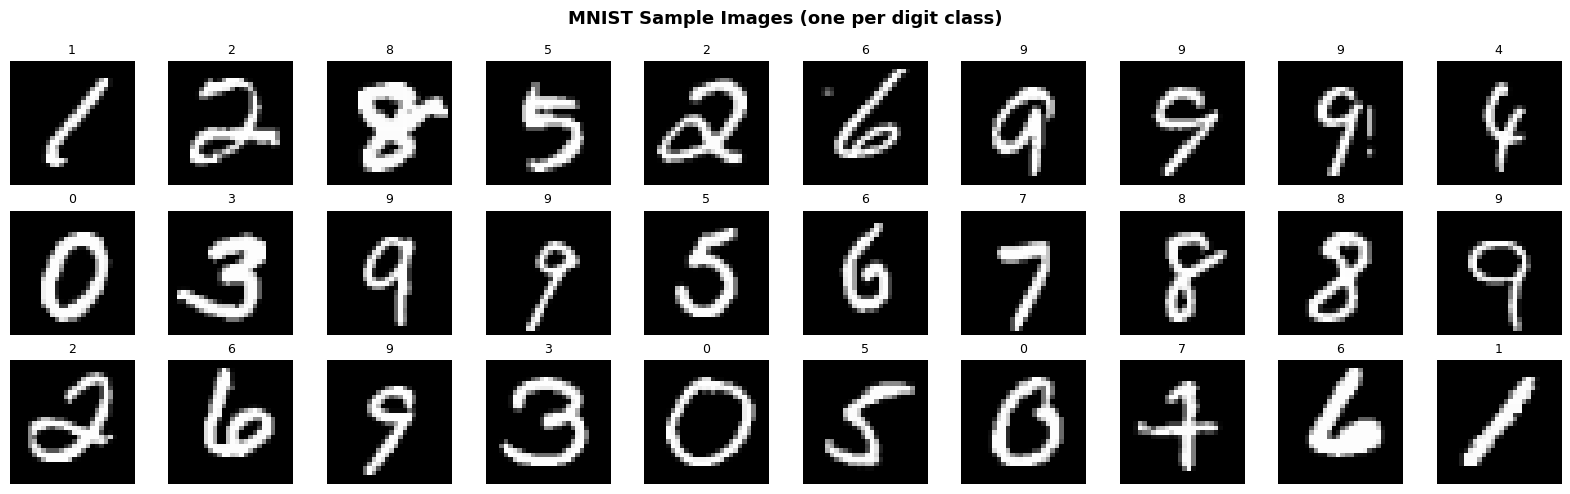

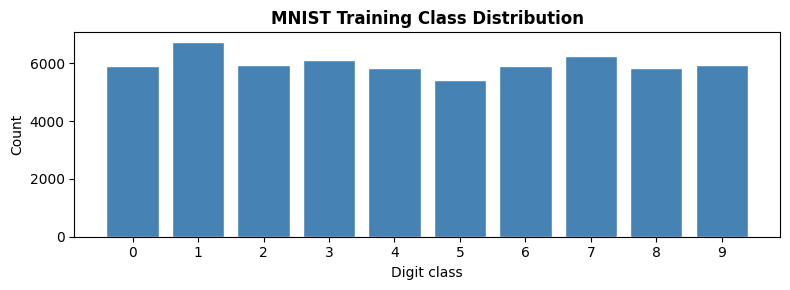

Dataset is well-balanced: 5421 – 6742 samples per class


In [ ]:
# ─────────────────────────────────────────────────────────────
# MNIST: 70,000 grayscale 28×28 images of digits 0–9.
# Normalisation uses dataset mean=0.1307 and std=0.3081
# as reported in LeCun et al. (1998).
# Training split: 60,000 | Test split: 10,000
# ─────────────────────────────────────────────────────────────

mnist_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST('./data', train=True,  download=True, transform=mnist_transform)
mnist_test  = datasets.MNIST('./data', train=False, download=True, transform=mnist_transform)

train_loader_mnist = DataLoader(mnist_train, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
test_loader_mnist  = DataLoader(mnist_test,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(mnist_train):,}')
print(f'Test  samples : {len(mnist_test):,}')
print(f'Classes       : {mnist_train.classes}')
print(f'Image shape   : {mnist_train[0][0].shape}')  # [1, 28, 28]

# ── Visualise sample images ───────────────────────────────────
imgs, lbls = next(iter(train_loader_mnist))
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i].squeeze(), cmap='gray')
    ax.set_title(str(lbls[i].item()), fontsize=9)
    ax.axis('off')
plt.suptitle('MNIST Sample Images (one per digit class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('t1_mnist_samples.png', dpi=150)
plt.show()

# ── Class distribution ────────────────────────────────────────
counts = np.bincount(mnist_train.targets.numpy())
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(10), counts, color='steelblue', edgecolor='white')
ax.set_xticks(range(10))
ax.set_xlabel('Digit class')
ax.set_ylabel('Count')
ax.set_title('MNIST Training Class Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('t1_class_dist.png', dpi=150)
plt.show()
print('Dataset is well-balanced:', counts.min(), '–', counts.max(), 'samples per class')

## T1-2 · CNN Architecture Definitions (4 Variants)

In [ ]:
# ─────────────────────────────────────────────────────────────
# Four architectures are compared systematically.
# Each builds on the previous to isolate the effect of each
# architectural component (LeCun et al., 1998;
# Ioffe & Szegedy, 2015; Srivastava et al., 2014;
# Simonyan & Zisserman, 2015).
#
# V1 Baseline  : 2 conv layers, ReLU, MaxPool
# V2 BatchNorm : + Batch Normalisation after each conv
# V3 Dropout   : + Dropout(0.5) in classifier head
# V4 Deep      : 3 conv layers, 128 filters, deeper FC
# ─────────────────────────────────────────────────────────────

class CNN_V1_Baseline(nn.Module):
    """2-layer CNN baseline — establishes minimum performance floor."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # → 14×14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)  # → 7×7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.classifier(self.features(x))


class CNN_V2_BatchNorm(nn.Module):
    """+ BatchNorm — stabilises training, reduces internal covariate shift
    (Ioffe & Szegedy, 2015)."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.classifier(self.features(x))


class CNN_V3_Dropout(nn.Module):
    """+ Dropout(0.5) — reduces co-adaptation of neurons
    (Srivastava et al., 2014)."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.classifier(self.features(x))


class CNN_V4_Deep(nn.Module):
    """3 conv layers with 128 filters — deeper representations as per
    VGG-style design (Simonyan & Zisserman, 2015). 3rd conv has no
    pooling to preserve spatial resolution before FC layers."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2), # → 14×14
            nn.Conv2d(32, 64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2), # → 7×7
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU()                   # → 7×7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*7*7, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.classifier(self.features(x))


# ── Parameter counts ──────────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for name, cls in [('V1_Baseline', CNN_V1_Baseline),
                   ('V2_BatchNorm', CNN_V2_BatchNorm),
                   ('V3_Dropout',  CNN_V3_Dropout),
                   ('V4_Deep',     CNN_V4_Deep)]:
    m = cls()
    print(f'{name:<20}: {count_params(m):>10,} parameters')

V1_Baseline         :    421,642 parameters
V2_BatchNorm        :    421,834 parameters
V3_Dropout          :    421,834 parameters
V4_Deep             :  1,701,578 parameters


## T1-3 · Training & Evaluation Functions

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(lbls).sum().item()
        total      += imgs.size(0)
    return total_loss / total, 100. * correct / total


def evaluate_mnist(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_lbls = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            total_loss += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            correct += preds.eq(lbls).sum().item()
            total   += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_lbls.extend(lbls.cpu().numpy())
    return total_loss / total, 100. * correct / total, all_preds, all_lbls


def run_mnist_experiment(name, model_cls, epochs=12):
    """Full training loop for one CNN variant. Returns model + history."""
    model     = model_cls().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'tr_loss':[], 'tr_acc':[], 'te_loss':[], 'te_acc':[]}

    print(f'\n{'─'*55}')
    print(f'Training {name}  ({count_params(model):,} params)')
    print(f'{'─'*55}')

    for ep in range(1, epochs+1):
        t0 = time.time()
        tr_loss, tr_acc              = train_one_epoch(model, train_loader_mnist, criterion, optimizer)
        te_loss, te_acc, preds, lbls = evaluate_mnist(model, test_loader_mnist, criterion)
        scheduler.step()

        history['tr_loss'].append(tr_loss)
        history['tr_acc'].append(tr_acc)
        history['te_loss'].append(te_loss)
        history['te_acc'].append(te_acc)

        print(f'Ep {ep:02d}/{epochs}  '
              f'TrLoss:{tr_loss:.4f}  TrAcc:{tr_acc:.2f}%  '
              f'TeLoss:{te_loss:.4f}  TeAcc:{te_acc:.2f}%  '
              f'({time.time()-t0:.1f}s)')

    print(f'Best Test Accuracy: {max(history["te_acc"]):.2f}%')
    return model, history, preds, lbls


print('Training functions defined.')

Training functions defined.


## T1-4 · Run All Four Experiments

In [ ]:
MNIST_EPOCHS = 10

mnist_experiments = [
    ('V1_Baseline',  CNN_V1_Baseline),
    ('V2_BatchNorm', CNN_V2_BatchNorm),
    ('V3_Dropout',   CNN_V3_Dropout),
    ('V4_Deep',      CNN_V4_Deep),
]

mnist_results = {}   # name → {history, model, preds, lbls}

for exp_name, exp_cls in mnist_experiments:
    model, history, preds, lbls = run_mnist_experiment(exp_name, exp_cls, MNIST_EPOCHS)
    mnist_results[exp_name] = {
        'model'  : model,
        'history': history,
        'preds'  : preds,
        'lbls'   : lbls
    }

print('\n=== All MNIST experiments complete ===')


───────────────────────────────────────────────────────
Training V1_Baseline  (421,642 params)
───────────────────────────────────────────────────────
Ep 01/10  TrLoss:0.1332  TrAcc:95.87%  TeLoss:0.0406  TeAcc:98.74%  (17.6s)
Ep 02/10  TrLoss:0.0403  TrAcc:98.75%  TeLoss:0.0329  TeAcc:98.85%  (17.3s)
Ep 03/10  TrLoss:0.0263  TrAcc:99.15%  TeLoss:0.0372  TeAcc:98.81%  (16.2s)
Ep 04/10  TrLoss:0.0165  TrAcc:99.49%  TeLoss:0.0277  TeAcc:99.14%  (16.4s)
Ep 05/10  TrLoss:0.0101  TrAcc:99.69%  TeLoss:0.0309  TeAcc:99.04%  (16.4s)
Ep 06/10  TrLoss:0.0064  TrAcc:99.80%  TeLoss:0.0322  TeAcc:99.11%  (16.5s)
Ep 07/10  TrLoss:0.0030  TrAcc:99.91%  TeLoss:0.0282  TeAcc:99.29%  (15.8s)
Ep 08/10  TrLoss:0.0014  TrAcc:99.97%  TeLoss:0.0264  TeAcc:99.24%  (15.7s)
Ep 09/10  TrLoss:0.0005  TrAcc:100.00%  TeLoss:0.0265  TeAcc:99.31%  (16.1s)
Ep 10/10  TrLoss:0.0003  TrAcc:100.00%  TeLoss:0.0263  TeAcc:99.31%  (16.0s)
Best Test Accuracy: 99.31%

───────────────────────────────────────────────────────
Tr

## T1-5 · Learning Curves — All Models

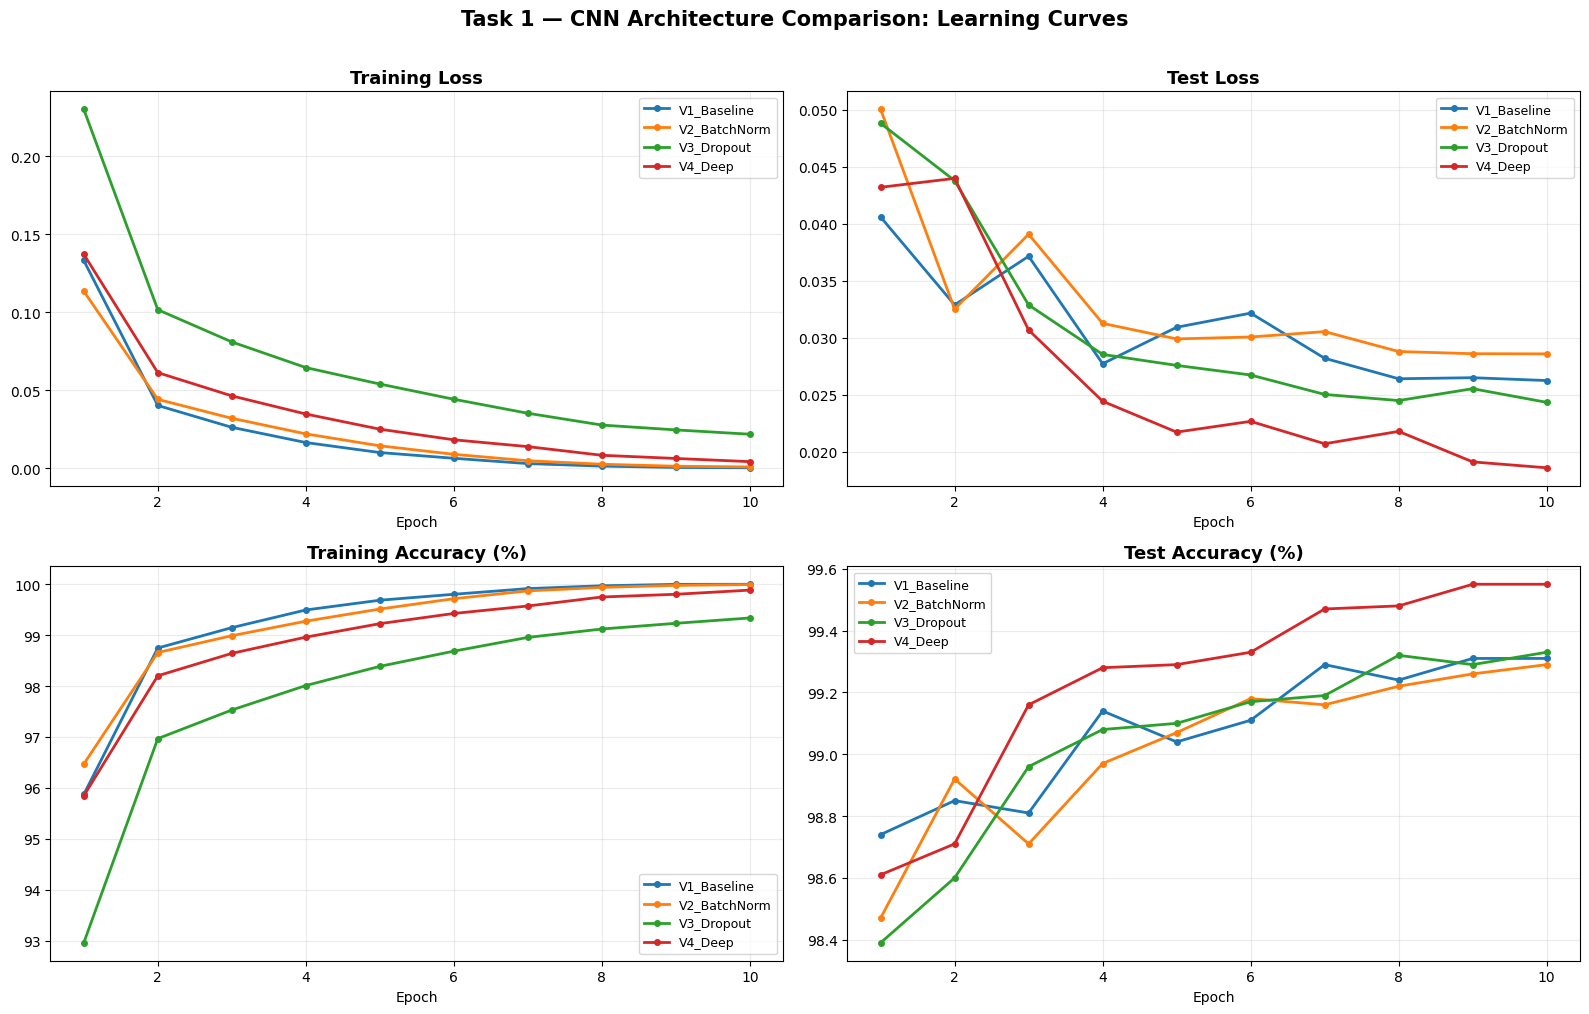

Saved: t1_learning_curves.png


In [ ]:
colours = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
epochs  = range(1, MNIST_EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
titles = ['Training Loss', 'Test Loss', 'Training Accuracy (%)', 'Test Accuracy (%)']
keys   = ['tr_loss', 'te_loss', 'tr_acc', 'te_acc']

for ax, title, key in zip(axes.flatten(), titles, keys):
    for (name, res), c in zip(mnist_results.items(), colours):
        ax.plot(epochs, res['history'][key], marker='o', ms=4,
                label=name, color=c, linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle('Task 1 — CNN Architecture Comparison: Learning Curves',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('t1_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: t1_learning_curves.png')

## T1-6 · Summary Table + Best Model Selection

In [ ]:
print('\n' + '='*70)
print(f'{"Model":<20} {"Best Acc":>10} {"Final TrAcc":>12} {"Final TeLoss":>13} {"Params":>10}')
print('='*70)

best_name_mnist, best_acc_mnist = None, 0.0

for (name, res), cls in zip(mnist_results.items(),
                              [CNN_V1_Baseline, CNN_V2_BatchNorm,
                               CNN_V3_Dropout, CNN_V4_Deep]):
    h     = res['history']
    best  = max(h['te_acc'])
    tr    = h['tr_acc'][-1]
    loss  = h['te_loss'][-1]
    np_   = count_params(cls())
    print(f'{name:<20} {best:>9.2f}% {tr:>11.2f}% {loss:>13.4f} {np_:>10,}')
    if best > best_acc_mnist:
        best_acc_mnist = best
        best_name_mnist = name

print('='*70)
print(f'\nBest model: {best_name_mnist}  ({best_acc_mnist:.2f}% test accuracy)')


Model                  Best Acc  Final TrAcc  Final TeLoss     Params
V1_Baseline              99.31%      100.00%        0.0263    421,642
V2_BatchNorm             99.29%       99.99%        0.0286    421,834
V3_Dropout               99.33%       99.34%        0.0243    421,834
V4_Deep                  99.55%       99.88%        0.0186  1,701,578

Best model: V4_Deep  (99.55% test accuracy)


## T1-7 · Detailed Evaluation of Best Model

In [ ]:
best_model_mnist = mnist_results[best_name_mnist]['model']
preds_best       = mnist_results[best_name_mnist]['preds']
lbls_best        = mnist_results[best_name_mnist]['lbls']

# ── Classification report ─────────────────────────────────────
print(f'Classification Report — {best_name_mnist}')
print(classification_report(lbls_best, preds_best,
                             target_names=[str(i) for i in range(10)]))

# ── Aggregate metrics ─────────────────────────────────────────
print(f'Macro F1    : {f1_score(lbls_best, preds_best, average="macro"):.4f}')
print(f'Macro Prec  : {precision_score(lbls_best, preds_best, average="macro"):.4f}')
print(f'Macro Recall: {recall_score(lbls_best, preds_best, average="macro"):.4f}')

Classification Report — V4_Deep
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      1.00       958
           7       0.99      1.00      1.00      1028
           8       1.00      1.00      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

Macro F1    : 0.9954
Macro Prec  : 0.9955
Macro Recall: 0.9954


## T1-8 · Confusion Matrix

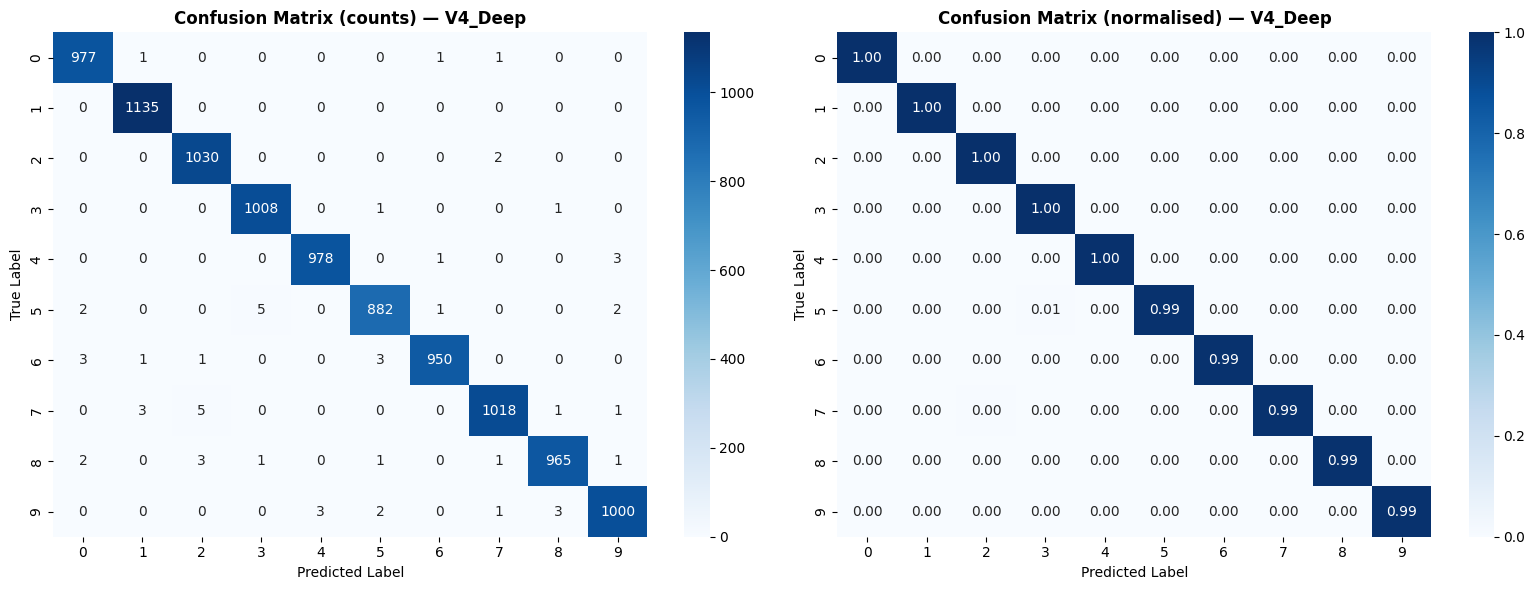

Saved: t1_confusion_matrix.png


In [ ]:
cm = confusion_matrix(lbls_best, preds_best)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_title(f'Confusion Matrix (counts) — {best_name_mnist}', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=range(10), yticklabels=range(10))
axes[1].set_title(f'Confusion Matrix (normalised) — {best_name_mnist}', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('t1_confusion_matrix.png', dpi=150)
plt.show()
print('Saved: t1_confusion_matrix.png')

## T1-9 · Misclassified Examples

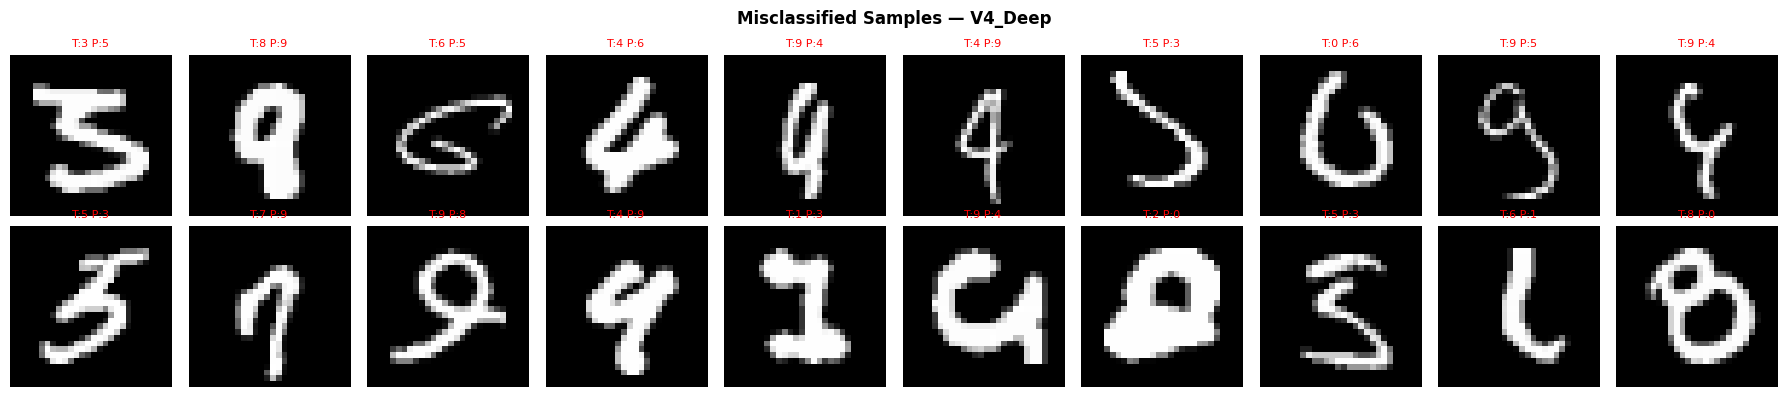

In [ ]:
best_model_mnist.eval()
mis_imgs, mis_true, mis_pred = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader_mnist:
        out   = best_model_mnist(imgs.to(device))
        preds = out.argmax(1).cpu()
        mask  = preds != lbls
        mis_imgs.extend(imgs[mask])
        mis_true.extend(lbls[mask].numpy())
        mis_pred.extend(preds[mask].numpy())
        if len(mis_imgs) >= 20: break

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(mis_imgs):
        ax.imshow(mis_imgs[i].squeeze(), cmap='gray')
        ax.set_title(f'T:{mis_true[i]} P:{mis_pred[i]}',
                     color='red' if mis_true[i] != mis_pred[i] else 'green', fontsize=8)
    ax.axis('off')
plt.suptitle(f'Misclassified Samples — {best_name_mnist}', fontweight='bold')
plt.tight_layout()
plt.savefig('t1_misclassified.png', dpi=150)
plt.show()

## T1-10 · Save Best MNIST Model

In [ ]:
torch.save(best_model_mnist.state_dict(), f't1_best_model_{best_name_mnist}.pth')
print(f'Saved: t1_best_model_{best_name_mnist}.pth')
print('\n✓ Task 1 complete.')

Saved: t1_best_model_V4_Deep.pth

✓ Task 1 complete.
